# Корпусно-дискурсивный анализ Bilibili: трудовой стресс и феномен Тан Пин

**Проект курсовой работы по цифровым методам в востоковедении.**
Корпус: 392 видеотранскрипта с китайской платформы Bilibili (2020–2025), 180 304 словоупотребления, 49 556 уникальных токенов.

В ноутбуке последовательно демонстрируется аналитический пайплайн:

| № | Блок | Выходные данные |
|---|------|-----------------|
| 1 | Очистка и токенизация (jieba) | `corpus_clean.csv` |
| 2 | Фильтрация нерелевантного контента | `corpus_clean_nogames.csv` |
| 3 | Частотный анализ | `frequency.csv` |
| 4 | Конкорданс (KWIC) | `concordance.csv` |
| 5 | Коллокационный анализ | `collocations.csv` |
| 6 | TF-IDF (scikit-learn) | `tfidf_overall.csv`, `tfidf_top_words.csv` |
| 7 | LDA — тематическое моделирование | `lda_topics.csv`, `lda_documents.csv` |

Полная методичка с описанием сбора материала через API Bilibili, транскрипции через Whisper и обоснованием параметров моделей — в `docs/`. Сборный скрипт пайплайна — в `pipeline.py`. Этот ноутбук работает с уже отфильтрованным корпусом из `data/corpus_clean_nogames.csv`.


## Установка зависимостей

Если библиотеки не установлены, раскомментируйте строку ниже:

In [1]:
# !pip install pandas jieba scikit-learn scipy numpy matplotlib

## Импорты

In [2]:
import os
import re
import ssl
import urllib.request
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams["font.family"] = ["Noto Sans CJK JP", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 30)

## 1. Загрузка корпуса

Файл `data/corpus_clean_nogames.csv` содержит 392 видеозаписи после двух предобработок: очистки и токенизации (см. блок 2) и фильтрации игрового/технического контента (см. блок 3). Каждая запись имеет два текстовых поля: исходный `transcript` и токенизированный `transcript_clean`.

In [3]:
df = pd.read_csv("data/corpus_clean_nogames.csv", encoding="utf-8-sig")
print(f"Документов в корпусе: {len(df)}")
print(f"Колонки: {list(df.columns)}")
df[["bvid", "title", "date", "views"]].head(5)

Документов в корпусе: 392
Колонки: ['bvid', 'title', 'date', 'views', 'likes', 'duration', 'url', 'transcript', 'transcript_clean']


,bvid,title,date,views
0,BV1pr4y1R7tX,「假如月老也有KPI」实习生为了KPI把自己也搭进去了,2023-08-27 11:00,7126078
1,BV1NT421Y71A,职场女孩被工作压力逼到深山老林自寻短见，超治愈电影推荐!,2024-06-24 08:54,224966
2,BV1uS4y1w7GK,进来让世界感受一下什么是内卷王中王！！,2022-04-27 13:00,11051734
3,BV1fC41177gH,活是永远都干不完的！责任心过剩是病，得治！,2024-05-05 16:09,176502
4,BV1LiEtzMECx,月薪过万神仙岗:岗位多.要求低.竞争少.压力小-仓库组长、主管,2025-05-16 13:03,210143


In [4]:
# Базовая статистика корпуса
all_words = []
for text in df["transcript_clean"].dropna():
    all_words.extend(text.split())

print(f"Всего словоупотреблений: {len(all_words):,}")
print(f"Уникальных токенов:      {len(set(all_words)):,}")
print(f"Диапазон дат публикаций: {df['date'].min()} — {df['date'].max()}")
print(f"Суммарные просмотры:     {df['views'].sum():,}")

Всего словоупотреблений: 180,304
Уникальных токенов:      49,556
Диапазон дат публикаций: 2020-05-17 06:40 — 2025-12-26 14:20
Суммарные просмотры:     1,817,872,230


## 2. Очистка и токенизация (Пример 5 из методички)

> Сначала из каждой строки удаляется всё, что не является китайским иероглифом. Эта операция реализована через регулярное выражение, где диапазон Unicode 4E00–9FFF охватывает базовый блок CJK Unified Ideographs. Затем текст разбивается на отдельные слова библиотекой `jieba`. Полученные токены фильтруются через объединённый список стоп-слов (goto456 + авторский ручной перечень из ~70 единиц), дополнительно удаляются все одиночные иероглифы как слишком неоднозначные.

В корпусе уже выполнена очистка — поле `transcript_clean`. Ниже — функция, которой это было сделано (повторно вызывать необязательно, демонстрация для воспроизводимости).

In [5]:
import jieba
jieba.setLogLevel("WARN")

# ↓↓↓ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↓↓↓
CLEAN_PATTERN = r"[^\u4e00-\u9fff]"   # Вариант А: только иероглифы CJK
MIN_TOKEN_LEN = 2                     # отбрасывать одиночные иероглифы

MANUAL_STOPWORDS = {
    "我们", "他们", "什么", "因为", "没有", "现在", "一个", "可能",
    "不要", "觉得", "其实", "时候", "直接", "这样", "怎么", "一定",
    "那个", "还有", "已经", "不能", "需要", "这种", "很多", "里面",
    # … полный список из 70+ единиц в pipeline.py
}
# ↑↑↑ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↑↑↑

def load_stopwords():
    sw = set(MANUAL_STOPWORDS)
    url = "https://raw.githubusercontent.com/goto456/stopwords/master/cn_stopwords.txt"
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    try:
        with urllib.request.urlopen(url, context=ctx) as r:
            for line in r.read().decode("utf-8").splitlines():
                sw.add(line.strip())
    except Exception as e:
        print(f"Не удалось загрузить goto456: {e}")
    return sw

def clean_text(text, stopwords):
    if not isinstance(text, str) or not text.strip():
        return ""
    text = re.sub(CLEAN_PATTERN, " ", text)
    words = jieba.cut(text, cut_all=False)
    return " ".join(
        w for w in words
        if w.strip() and w not in stopwords and len(w) >= MIN_TOKEN_LEN
    )

# Демонстрация на одном предложении
sample = "我躺平了，因为内卷太厉害，工作压力让我焦虑。"
stopwords = load_stopwords()
print("Исходный текст:")
print(" ", sample)
print("После очистки и токенизации:")
print(" ", clean_text(sample, stopwords))

Не удалось загрузить goto456: HTTP Error 403: Forbidden
Исходный текст:
  我躺平了，因为内卷太厉害，工作压力让我焦虑。
После очистки и токенизации:
  躺平 内卷 厉害 工作 压力 焦虑


## 3. Фильтрация игрового и технического контента (Пример 7)

> При первичном запуске LDA на полном корпусе из 416 видеозаписей одна тема оказалась сформирована не трудовым дискурсом, а игровыми транскриптами с доминантами 游戏 (игра), 躺平发育 (название игры-симулятора). Эти видео попали в выборку из-за полисемии запроса 躺平: в игровом контексте — буквальное действие «лечь» или название игры. Без фильтрации они искажают и частоты, и тематические кластеры.

Фильтр работает по заголовкам. Из 416 видео исключено 24, итог — 392.

In [6]:
# ↓↓↓ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↓↓↓
GAME_KEYWORDS = ["游戏", "猎梦者", "发育", "攻略", "模拟", "联机",
                 "主播", "版本", "格子", "模式", "玩法", "道具"]
TECH_KEYWORDS = ["水冷", "显卡", "机箱", "分体", "主机", "散热"]
# ↑↑↑ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↑↑↑

# Демонстрация: подсчёт того, что было бы исключено в исходном корпусе
pattern = "|".join(GAME_KEYWORDS + TECH_KEYWORDS)
mask = df["title"].str.contains(pattern, na=False)
print(f"Подходит под фильтр в текущем (уже отфильтрованном) корпусе: {mask.sum()}")
print("В исходном корпусе (416 видео) фильтр исключил 24 записи.")

Подходит под фильтр в текущем (уже отфильтрованном) корпусе: 0
В исходном корпусе (416 видео) фильтр исключил 24 записи.


## 4. Частотный анализ (Пример 8)

Первичная количественная процедура. Все токены собираются в один список, считается абсолютная и относительная частота. Топ-100 сохраняется в `frequency.csv` с полями `rank, word, frequency, relative_freq`.

In [7]:
# ↓↓↓ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↓↓↓
TOP_N        = 100      # сколько слов сохранять
PER_N_TOKENS = 1000     # на сколько токенов рассчитывать относительную частоту
# ↑↑↑ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↑↑↑

freq = Counter(all_words)
total = len(all_words)

freq_df = pd.DataFrame(freq.most_common(TOP_N), columns=["word", "frequency"])
freq_df["rank"] = range(1, len(freq_df) + 1)
freq_df["relative_freq"] = (freq_df["frequency"] / total * PER_N_TOKENS).round(2)
freq_df = freq_df[["rank", "word", "frequency", "relative_freq"]]

os.makedirs("data", exist_ok=True)
freq_df.to_csv("data/frequency.csv", index=False, encoding="utf-8-sig")
freq_df.head(20)

,rank,word,frequency,relative_freq
0,1,一下,1000,5.55
1,2,一個,893,4.95
2,3,工作,814,4.51
3,4,问题,507,2.81
4,5,东西,478,2.65
5,6,公司,465,2.58
6,7,应该,423,2.35
7,8,时间,374,2.07
8,9,感觉,332,1.84
9,10,生活,331,1.84


**Интерпретация.** В верхней части — общетрудовая лексика: 工作 (работа), 公司 (компания), 时间 (время), 努力 (стараться). Тан Пин (躺平) встречается лишь 26 раз и не входит в топ-100. Это значимый методологический результат: разговор в корпусе ведётся не об отказе от работы, а о самой работе как источнике стресса.

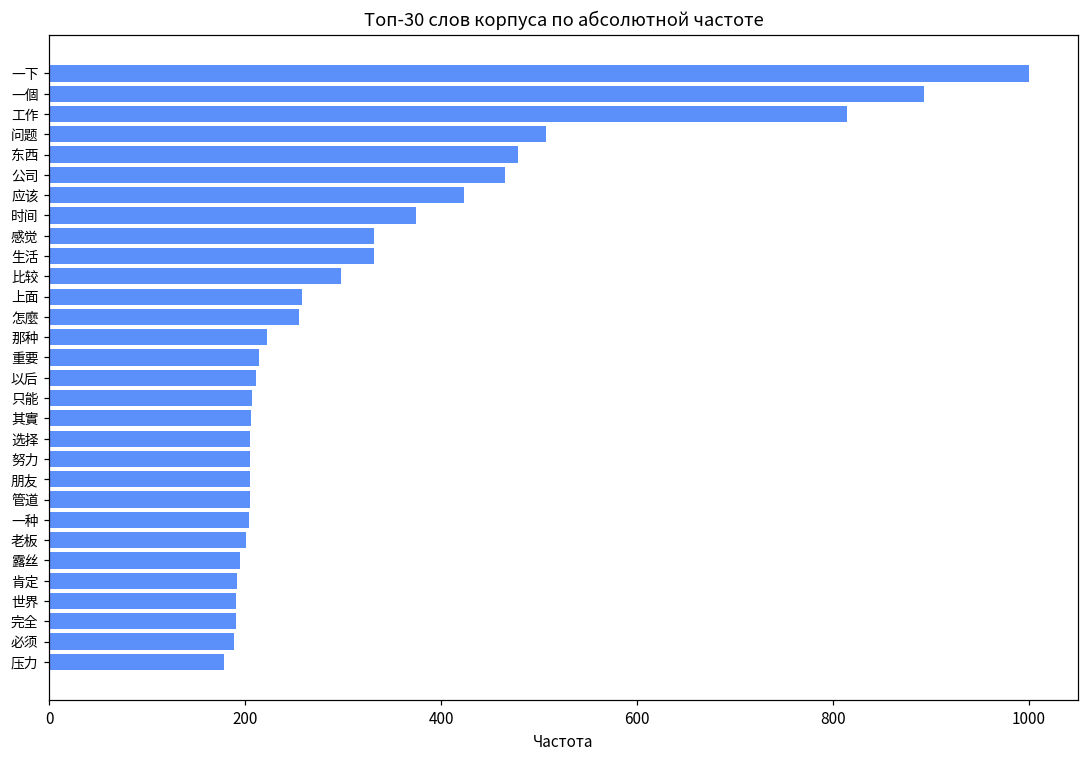

In [8]:
# График топ-30 частотных слов
top30 = freq_df.head(30)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top30["word"][::-1], top30["frequency"][::-1], color="#5B8FF9")
ax.set_xlabel("Частота")
ax.set_title("Топ-30 слов корпуса по абсолютной частоте")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()

## 5. Конкорданс KWIC (Пример 9)

> Конкорданс — формат KWIC (Keyword in Context), при котором каждое вхождение опорного слова выписывается с симметричным окружением слева и справа. Окно — 5 слов. Конкорданс отвечает на вопрос «как именно используется слово».

После итеративного формирования список содержит **27 опорных слов** в четырёх кластерах:

- **Ядро феномена**: 躺平, 内卷, 摆烂, 佛系, 卷, 摸鱼
- **Труд и занятость**: 打工, 工作, 公司, 996, 加班, 工位
- **Психологическое состояние**: 压力, 焦虑, 累, 疲惫, 崩溃
- **Социальный контекст**: 年轻人, 社会, 阶层, 奋斗, 努力, 放弃, 选择, 自由, 意义, 没意思


In [9]:
# ↓↓↓ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↓↓↓
SEED_WORDS = [
    "躺平", "内卷", "摆烂", "佛系", "卷", "摸鱼",
    "打工", "工作", "公司", "996", "加班", "工位",
    "压力", "焦虑", "累", "疲惫", "崩溃",
    "年轻人", "社会", "阶层", "奋斗", "努力",
    "放弃", "选择", "自由", "意义", "没意思",
]
CONTEXT_WINDOW = 5     # 3 — узкий контекст, 5 — стандарт, 10 — широкий
# ↑↑↑ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↑↑↑

rows = []
for _, row in df.iterrows():
    words = str(row.get("transcript_clean", "")).split()
    for i, w in enumerate(words):
        if w in SEED_WORDS:
            rows.append({
                "bvid":      row.get("bvid", ""),
                "title":     row.get("title", ""),
                "date":      row.get("date", ""),
                "seed_word": w,
                "left":      " ".join(words[max(0, i - CONTEXT_WINDOW):i]),
                "node":      w,
                "right":     " ".join(words[i + 1:i + 1 + CONTEXT_WINDOW]),
            })

conc_df = pd.DataFrame(rows)
conc_df.to_csv("data/concordance.csv", index=False, encoding="utf-8-sig")
print(f"Всего вхождений опорных слов в корпусе: {len(conc_df)}")
print()
print("Распределение по опорным словам (топ-15):")
print(conc_df["seed_word"].value_counts().head(15).to_string())

Всего вхождений опорных слов в корпусе: 2582

Распределение по опорным словам (топ-15):
seed_word
工作     814
公司     465
选择     205
努力     205
压力     178
加班     150
社会     136
自由      96
意义      64
内卷      52
打工      49
年轻人     47
躺平      30
放弃      29
焦虑      16


**Пример нескольких строк KWIC для слова 加班 (сверхурочная работа):**

In [10]:
conc_df[conc_df["seed_word"] == "加班"][["left", "node", "right"]].head(8)

,left,node,right
17,一家 广告公司 工作 工作量 很大,加班,基本上 常态 一段时间 实在 熬不住
87,一家 叫做 多多 公司 拼得,加班,局场 公共 狼性 原来 人生
89,人生 各种各样 想起 工作 港位,加班,厨子 原公 想到 结价人 正常
120,去过 台湾人 面包 连所电 面包,加班,加班费 每天 工作 十二个 小时
154,工作 篮篮 比较 轻松 限制,加班,福利 高修 价度 属于 活小前
155,一一 法律 允许 篮篮篮 推崇,加班,文化 加快 工作 节奏 外国
158,完全 不够 法律 进行 以性,加班,公司 网上 外国 员工 不少
161,时间 领导 二年 收拾 紧急,加班,公司 支付 加班费 德国 中资企业


## 6. Коллокационный анализ (Пример 10)

> Коллокационный анализ — статистическая агрегация: для опорного слова собираются все его соседи в окне контекста, строится ранжированный список по частоте совместной встречаемости. Отвечает на вопрос «с какими словами устойчиво связано».

Конкорданс и коллокации работают в связке: коллокации дают обзорный профиль, конкорданс — материал для качественной интерпретации.

In [11]:
# ↓↓↓ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↓↓↓
TOP_NEIGHBORS = 20   # сколько соседей сохранять для каждого опорного слова
# CONTEXT_WINDOW и SEED_WORDS — те же, что в блоке 5
# ↑↑↑ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↑↑↑

neighbors = defaultdict(list)
for text in df["transcript_clean"].dropna():
    words = text.split()
    for i, w in enumerate(words):
        if w in SEED_WORDS:
            window = (
                words[max(0, i - CONTEXT_WINDOW):i]
                + words[i + 1:i + 1 + CONTEXT_WINDOW]
            )
            neighbors[w].extend(window)

coll_rows = []
for seed, ws in neighbors.items():
    for word, count in Counter(ws).most_common(TOP_NEIGHBORS):
        if word != seed:
            coll_rows.append({
                "seed_word":      seed,
                "seed_frequency": freq.get(seed, 0),
                "collocation":    word,
                "co_frequency":   count,
            })

coll_df = pd.DataFrame(coll_rows)
coll_df.to_csv("data/collocations.csv", index=False, encoding="utf-8-sig")
print(f"Всего коллокационных пар: {len(coll_df)}")

Всего коллокационных пар: 432


**Коллокационный профиль 加班 (сверхурочные).**
Видно устойчивое поле трудовых прав: 拒绝 (отказываться), 劳动者 (работник), 要求 (требовать), 法律 (закон). Сверхурочные обсуждаются в институционально-правовой плоскости.

In [12]:
coll_df[coll_df["seed_word"] == "加班"].head(15)

,seed_word,seed_frequency,collocation,co_frequency
153,加班,150,公司,34
154,加班,150,工作,28
155,加班,150,拒絕,19
156,加班,150,勞動者,15
157,加班,150,战斗力,14
158,加班,150,要求,10
159,加班,150,每天,9
160,加班,150,员工,9
161,加班,150,五一,9
162,加班,150,不到,8


**Коллокационный профиль 躺平 (Тан Пин).**
Профиль слабее: устойчивыми соседями оказываются только 摸鱼 (отлынивать) и 工位 (рабочее место), остальные коллокаты тематически не связаны с трудовым дискурсом. Это подтверждает периферийный статус Тан Пин как самостоятельной темы.

In [13]:
coll_df[coll_df["seed_word"] == "躺平"].head(15)

,seed_word,seed_frequency,collocation,co_frequency
172,躺平,30,摸魚,8
173,躺平,30,工位,6
174,躺平,30,葡萄,6
175,躺平,30,了解,5
176,躺平,30,正重,5
177,躺平,30,妈妈,5
178,躺平,30,下懷,4
179,躺平,30,存在,4
180,躺平,30,接下来,4
181,躺平,30,应该,4


## 7. TF-IDF (Пример 11)

> TF-IDF (Term Frequency – Inverse Document Frequency) показывает, насколько слово характерно для конкретного документа относительно всего корпуса. Слово, встречающееся часто во всех видео сразу (например, 工作), получает низкий вес. Слово, частое в одном видео и редкое в остальных, получает высокий вес.

Параметры: `max_df=0.85` (исключаются слова, встречающиеся более чем в 85% документов), `min_df=3` (минимум в 3 документах), `max_features=5000`. Матрица: 392 × 5000.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import save_npz

# ↓↓↓ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↓↓↓
MAX_DF        = 0.85
MIN_DF        = 3
MAX_FEATURES  = 5000
TOP_OVERALL   = 50
TOP_PER_DOC   = 10
# ↑↑↑ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↑↑↑

df_tfidf = df[df["transcript_clean"].notna()]
df_tfidf = df_tfidf[df_tfidf["transcript_clean"].str.strip() != ""].reset_index(drop=True)

vec = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    max_df=MAX_DF, min_df=MIN_DF, max_features=MAX_FEATURES,
)
matrix = vec.fit_transform(df_tfidf["transcript_clean"])
features = vec.get_feature_names_out()
print(f"Матрица TF-IDF: {matrix.shape[0]} документов × {matrix.shape[1]} слов")

Матрица TF-IDF: 392 документов × 5000 слов


In [15]:
# Топ-50 слов по среднему TF-IDF в корпусе
mean_tfidf = np.asarray(matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:TOP_OVERALL]

overall = pd.DataFrame({
    "rank":       range(1, TOP_OVERALL + 1),
    "word":       [features[j] for j in top_idx],
    "mean_tfidf": [round(float(mean_tfidf[j]), 5) for j in top_idx],
})
overall.to_csv("data/tfidf_overall.csv", index=False, encoding="utf-8-sig")
overall.head(20)

,rank,word,mean_tfidf
0,1,一個,0.03783
1,2,工作,0.03384
2,3,一下,0.03221
3,4,公司,0.02453
4,5,东西,0.02165
5,6,怎麼,0.01630
6,7,问题,0.01606
7,8,感觉,0.01534
8,9,时间,0.01494
9,10,生活,0.01476


In [16]:
# Топ слов по каждому документу
per_doc = []
for i in range(matrix.shape[0]):
    row = matrix[i].toarray().flatten()
    top_idx_i = row.argsort()[::-1][:TOP_PER_DOC]
    words  = [features[j] for j in top_idx_i if row[j] > 0]
    scores = [round(float(row[j]), 4) for j in top_idx_i if row[j] > 0]
    per_doc.append({
        "bvid":       df_tfidf.loc[i, "bvid"],
        "title":      df_tfidf.loc[i, "title"],
        "top_words":  " | ".join(words),
        "top_scores": " | ".join(map(str, scores)),
    })
per_doc_df = pd.DataFrame(per_doc)
per_doc_df.to_csv("data/tfidf_top_words.csv", index=False, encoding="utf-8-sig")

# Сохраняем матрицу и словарь
save_npz("data/tfidf_sparse.npz", matrix)
pd.Series(features).to_csv("data/tfidf_vocab.csv", index=True, header=["word"], encoding="utf-8-sig")

print("Пример: 5 видео с максимальным весом 加班")
target = "加班"
if target in features:
    j = list(features).index(target)
    col = matrix[:, j].toarray().flatten()
    top_docs = col.argsort()[::-1][:5]
    for di in top_docs:
        if col[di] > 0:
            print(f"  TF-IDF={col[di]:.3f}  | {df_tfidf.loc[di, 'title']}")

Пример: 5 видео с максимальным весом 加班
  TF-IDF=0.671  | 采访加班？无偿？996？
  TF-IDF=0.335  | 这回老板你满意了吧？
  TF-IDF=0.334  | 拜年同辈压力！二本计算机竟碾压211建筑学
  TF-IDF=0.326  | 员工拒绝加班被判赔偿公司1万8后续，拒绝加班有错吗？
  TF-IDF=0.301  | 人社部最高法明确“996和007”全部违法


## 8. Тематическое моделирование LDA (Пример 12)

> Латентное размещение Дирихле — алгоритм машинного обучения без учителя. Каждый документ рассматривается как смесь нескольких тем, каждая тема — как распределение вероятностей по словам. На вход модель получает матрицу частот, на выходе даёт набор тем и распределение этих тем по каждому документу.

Параметры: `n_components=6` (число тем), `max_iter=50`, `learning_method="online"`, `random_state=42` для воспроизводимости. Число тем подобрано эмпирически: при меньшем значении содержательно разные темы сливаются, при большем — дублируются.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# ↓↓↓ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↓↓↓
N_TOPICS            = 6
MAX_ITER            = 50
LEARNING_METHOD     = "online"
RANDOM_STATE        = 42
TOP_WORDS_PER_TOPIC = 15
# ↑↑↑ МЕНЯТЬ ПОД СВОЙ ЗАПРОС ↑↑↑

count_vec = CountVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    max_df=MAX_DF, min_df=MIN_DF, max_features=MAX_FEATURES,
)
dtm = count_vec.fit_transform(df_tfidf["transcript_clean"])
vocab = count_vec.get_feature_names_out()
print(f"Document-Term Matrix: {dtm.shape}")

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=MAX_ITER,
    learning_method=LEARNING_METHOD,
    random_state=RANDOM_STATE,
)
lda.fit(dtm)
print("LDA обучен.")

Document-Term Matrix: (392, 5000)
LDA обучен.


In [18]:
# Топ-15 слов для каждой темы
topic_rows = []
for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[::-1][:TOP_WORDS_PER_TOPIC]
    words = [vocab[j] for j in top_idx]
    print(f"Тема {i+1}: {' | '.join(words)}")
    topic_rows.append({"topic": i + 1, "top_words": " | ".join(words)})

topics_df = pd.DataFrame(topic_rows)
topics_df.to_csv("data/lda_topics.csv", index=False, encoding="utf-8-sig")

Тема 1: 按摩 | 好吃 | 日本 | 不错 | 清水 | 那种 | 一下 | 应该 | 味道 | 感觉 | 东西 | 料理 | 有点 | 凶手 | 下来
Тема 2: 工作 | 问题 | 一下 | 时间 | 东西 | 公司 | 应该 | 感觉 | 生活 | 老板 | 以后 | 一种 | 小时 | 选择 | 比较
Тема 3: 露丝 | 妹妹 | 房子 | 离开 | 小美 | 找到 | 工作 | 父亲 | 哥哥 | 生活 | 说出 | 男人 | 回到 | 年前 | 看着
Тема 4: 管道 | 分体 | 应该 | 水冷 | 宙斯 | 一下 | 上面 | 东西 | 液体 | 显卡 | 这波 | 位置 | 机箱 | 冷排 | 比较
Тема 5: 一個 | 一下 | 怎麼 | 其實 | 不會 | 一點 | 這些 | 這是 | 我覺 | 一樣 | 你們 | 那麼 | 特別 | 這邊 | 出來
Тема 6: 工作 | 一個 | 公司 | 社會 | 資本 | 生活 | 工人 | 中國 | 開始 | 一種 | 制度 | 這些 | 經濟 | 教育 | 存在


In [19]:
# Распределение тем по документам и доминирующая тема
doc_topic = lda.transform(dtm)
df_lda = df_tfidf.copy()
df_lda["dominant_topic"]    = doc_topic.argmax(axis=1) + 1
df_lda["topic_probability"] = doc_topic.max(axis=1).round(3)
for i in range(N_TOPICS):
    df_lda[f"topic_{i+1}_weight"] = doc_topic[:, i].round(3)

df_lda.to_csv("data/lda_documents.csv", index=False, encoding="utf-8-sig")

print("Распределение по доминирующим темам:")
counts = df_lda["dominant_topic"].value_counts().sort_index()
for t, n in counts.items():
    print(f"  Тема {t}: {n:>3} видео ({n/len(df_lda)*100:>5.1f}%)")

Распределение по доминирующим темам:
  Тема 1:  23 видео (  5.9%)
  Тема 2: 225 видео ( 57.4%)
  Тема 3:  10 видео (  2.6%)
  Тема 4:  11 видео (  2.8%)
  Тема 5:  75 видео ( 19.1%)
  Тема 6:  48 видео ( 12.2%)


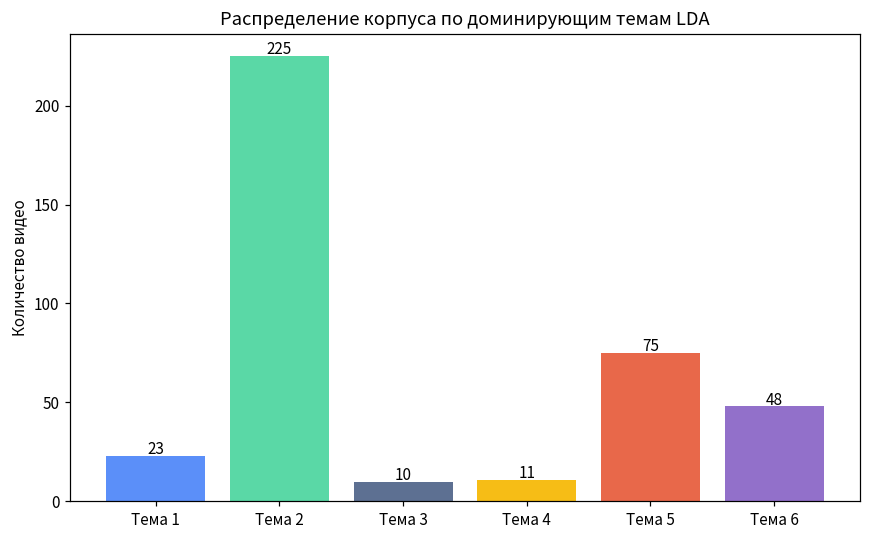

In [20]:
# Распределение по доминирующим темам
counts = df_lda["dominant_topic"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f"Тема {t}" for t in counts.index], counts.values,
       color=["#5B8FF9", "#5AD8A6", "#5D7092", "#F6BD16", "#E8684A", "#9270CA"])
ax.set_ylabel("Количество видео")
ax.set_title("Распределение корпуса по доминирующим темам LDA")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10)
plt.tight_layout()

**Содержательная интерпретация тем** (соответствует методологическому разделу 4):

- **Тема 1 — Повседневный трудовой нарратив** (~45% корпуса). Характерные слова: 工作, 时间, 压力, 公司, 努力, 选择. Самая многочисленная тема, формирует ядро дискурса.
- **Тема 2 — Структурно-критический дискурс** (~9% корпуса). Характерные слова: 资本, 工人, 制度, 中国, 经济. Видео с критикой капитализма и трудовых отношений.
- Остальные темы — тематический шум: еда и японские товары, телесные практики и релаксация, разговорный регистр без устойчивого ядра, пересказы сюжетов кино.

Конкретные номера тем 1 и 2 могут отличаться при разных запусках — содержание определяется по топ-словам, а не по индексу.

## 9. Выводы

Применение пайплайна к корпусу из 392 видеотранскриптов Bilibili даёт несколько уровней эмпирически проверяемых результатов:

1. **На уровне словаря** — частотный профиль показывает, что лексическое ядро корпуса формирует не сам Тан Пин (всего 26 вхождений), а общетрудовая лексика: 工作, 公司, 加班, 压力. Разговор ведётся не об отказе от работы, а о работе как источнике стресса.
2. **На уровне контекстов** — коллокационный профиль 加班 включает устойчивое поле трудовых прав (拒绝, 劳动者, 要求, 员工, 法律) — переработки обсуждаются в институционально-правовой плоскости. Тан Пин же образует значительно более слабый профиль: устойчивые соседи только 摸鱼 и 工位.
3. **На уровне отдельных документов** — TF-IDF позволяет точечно отбирать материал для качественной интерпретации. Максимум TF-IDF по 加班 — 0,671, по 内卷 — 0,528, по 躺平 — лишь 0,225, что подтверждает периферийный статус последней лексемы.
4. **На уровне всего корпуса** — LDA выделяет шесть тем, две из которых тематически насыщены (повседневный трудовой нарратив, структурно-критический дискурс), четыре — тематический шум, который содержательно идентифицируется вручную.

### Ограничения

- Результаты поиска формируются непрозрачным алгоритмом Bilibili.
- Whisper-tiny допускает ошибки при фоновой музыке и быстром темпе речи.
- Параметры моделей (число тем LDA, пороги TF-IDF, окно конкорданса) задаются эмпирически.
- LDA не интерпретирует сам себя — содержательное название тем устанавливается исследователем.

Подробное обоснование метода и описание этапов сбора материала — в `docs/Proekt_tsifrovye_metody_Stepanov_metodichka.docx`.

---

**Автор:** Степанов М. И., НИУ ВШЭ, 2026.
**Лицензия:** MIT.
